<a href="https://colab.research.google.com/github/a01056549975-ui/aipro/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##구글 드라이브 마운트
로컬에 있는 파일을 구글 드라이브에 업로드한 후 사용하기 위함

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks')

In [ ]:
!ls

 contact.py	  prompt_CheatSheet.txt  '강의안(0629).pdf'
 data.txt	  readme.txt		 '파이썬기본문법1선기쁨.ipynb .ipynb'
 first.ipynb	  Untitled0.ipynb	  파이썬기본문법2선기쁨.ipynb
 grade.csv	  Untitled1.ipynb
 inspection.txt   Untitled2.ipynb


* 필수 라이브러리 로드

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

print('python', sys.version.split()[0])
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('matplotlib', mpl.__version__)
print('seaborn', sns.__version__)

mpl.rcParams['axes.unicode_minus'] = False # - 기호 깨짐 방지


python 3.12.13
numpy 2.0.2
pandas 2.2.2
matplotlib 3.10.0
seaborn 0.13.2


## Step 1. Matplotlib 기본 패턴(최소 코드)

### 해야 할 것
- import → 데이터 준비
- `plt.plot()`으로 그리기
- `title/xlabel/ylabel` 넣고 `show()`

### 체크
- 선그래프 1개가 뜨고 제목/축 라벨이 보인다.

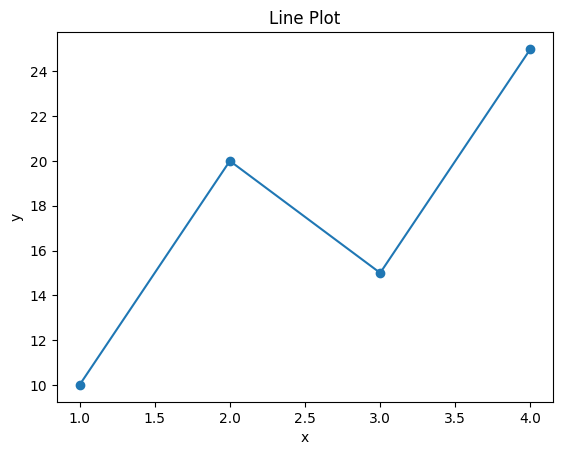

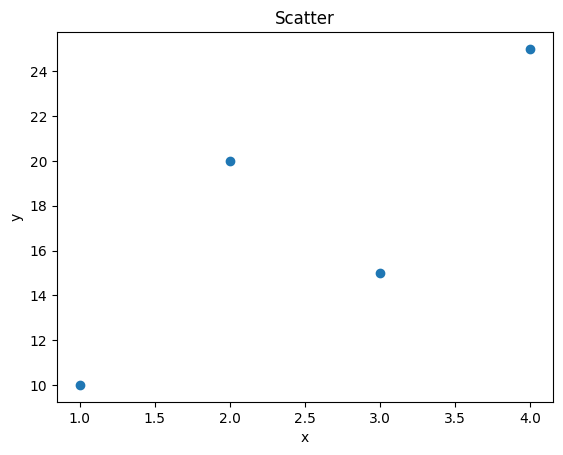

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [10, 20, 15, 25]

plt.plot(x, y,marker='o')
plt.title('Line Plot')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.scatter(x, y)
plt.title('Scatter')
plt.xlabel('x')
plt.ylabel('y')
plt.show()



## Step 2. 선그래프(Line) — 시간에 따른 변화

### 해야 할 것
- x축=시간(또는 순서), y축=값
- `marker='o'`로 점 확인
- `grid(True)`로 격자 표시

### 체크
- 요일별 걸음 수 추세를 선으로 읽을 수 있다.

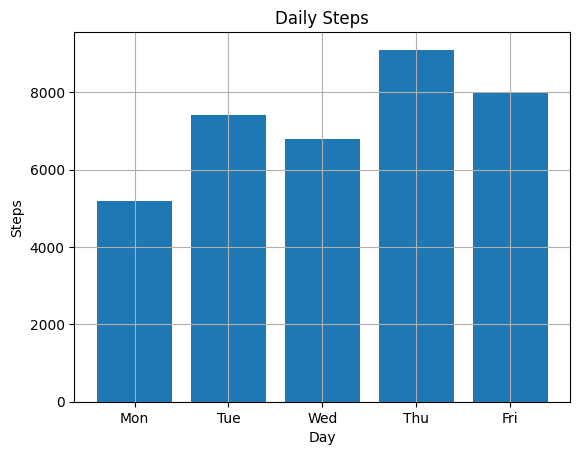

In [ ]:
import matplotlib.pyplot as plt

days = ['Mon','Tue','Wed','Thu','Fri']
steps = [5200, 7400, 6800, 9100, 8000]

#plt.plot(days, steps, marker='o') # 선그래프
plt.bar(days, steps) #막대그래프
plt.title('Daily Steps')
plt.xlabel('Day')
plt.ylabel('Steps')
plt.grid(True)
plt.show()


## Step 3. 막대그래프(Bar) — 범주 비교

### 해야 할 것
- `labels=범주`, `values=값`
- label이 길면 회전(rotation) 고려

### 체크
- A/B/C 막대가 나타나고 B가 가장 크다.

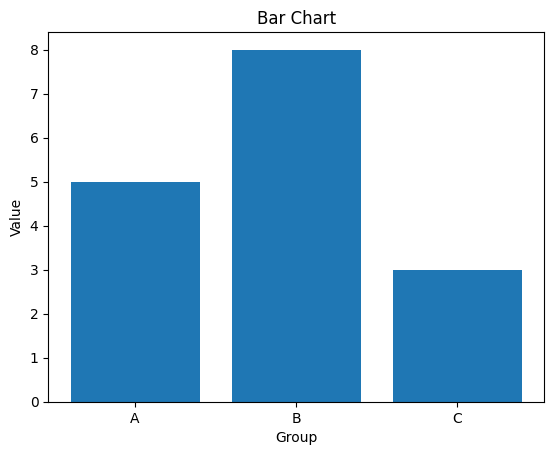

In [ ]:
import matplotlib.pyplot as plt

labels = ['A', 'B', 'C']
values = [5, 8, 3]

plt.bar(labels, values)
plt.title('Bar Chart')
plt.xlabel('Group')
plt.ylabel('Value')
plt.show()


## Step 4. 히스토그램(Histogram) — 분포 보기

### 해야 할 것
- `data`는 숫자 리스트/배열
- `bins`로 구간 수 조절

### 체크
- 연속 구간 막대가 나오며 분포 모양을 관찰할 수 있다.

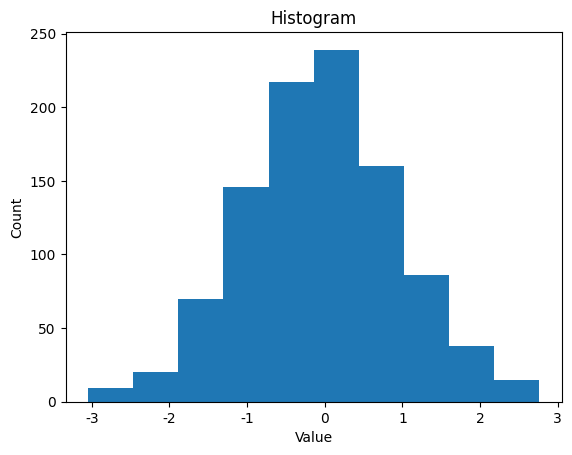

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # (선택) 실행할 때마다 비슷한 결과를 보고 싶다면
data = np.random.randn(1000)

plt.hist(data, bins=10)
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()


## Step 5. 산점도(Scatter) — 두 변수 관계

### 해야 할 것
- x=변수1, y=변수2
- 점의 퍼짐을 보고 관계/이상치(outlier)를 관찰

### 체크
- 점들이 찍히고 관계를 추측할 수 있다.

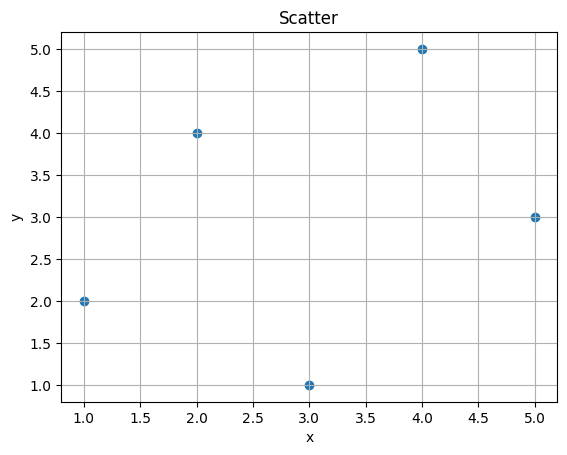

In [ ]:
import matplotlib.pyplot as plt

x = [1,2,3,4,5]
y = [2,4,1,5,3]

plt.scatter(x, y)
plt.title('Scatter')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


## Step 6. 여러 선 + 범례(legend)

### 해야 할 것
- 각 선에 `label` 지정
- `plt.legend()`로 범례 표시

### 체크
- A/B 두 선이 보이고 범례에 A, B가 표시된다.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Install Nanum Gothic font (if not already installed)
!apt-get install -y fonts-nanum > /dev/null 2>&1

# Remove existing font cache to ensure new fonts are registered
if os.path.exists('/root/.cache/matplotlib'):
    !rm -rf /root/.cache/matplotlib

# Rebuild font cache and set the font globally
fm._load_fontmanager(try_read_cache=False) # Force rebuild
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # Disable minus sign breaking

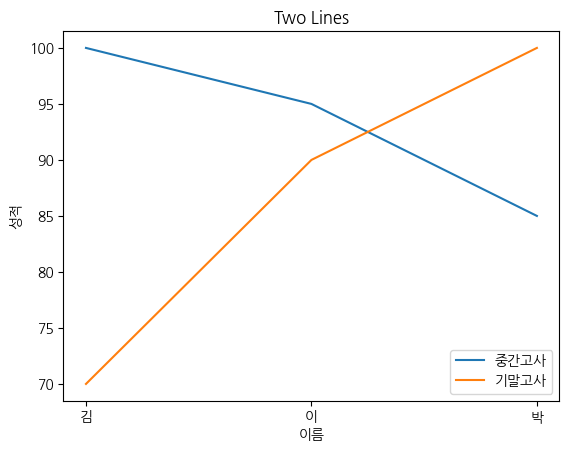

In [ ]:
import matplotlib.pyplot as plt

x = ["김","이","박"]
a = [100, 95, 85]
b = [70, 90, 100]

plt.plot(x, a, label='중간고사')
plt.plot(x, b, label='기말고사')
plt.title('Two Lines')
plt.xlabel('이름')
plt.ylabel('성적')
plt.legend()
plt.show()


## Step 7. 그래프 저장(`savefig`) — `show()`보다 먼저

### 해야 할 것
- 파일명(경로 포함) 정하기
- `plt.savefig()`는 `plt.show()`보다 먼저 호출

### 체크
- 현재 폴더에 `figure.png`가 생긴다.

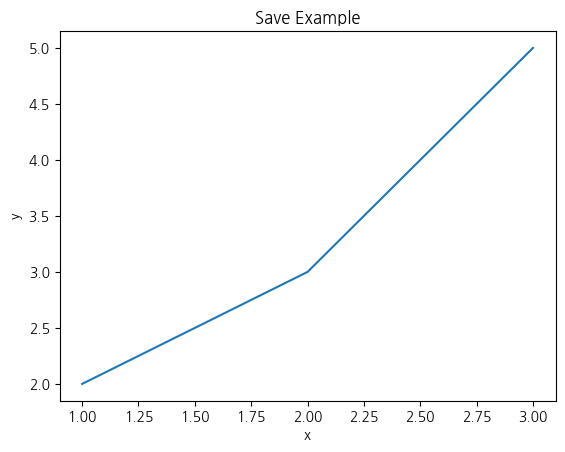

saved: figure.png


In [ ]:
import matplotlib.pyplot as plt

plt.plot([1,2,3], [2,3,5])
plt.title('Save Example')
plt.xlabel('x')
plt.ylabel('y')

plt.savefig('figure.png')
plt.show()

print('saved: figure.png')


## Step 8. Pandas로 빠르게 그리기(`plot kind`)

### 해야 할 것
- DataFrame 생성(또는 CSV 읽기)
- `df[col].plot(kind=...)`

### 체크
- score 분포 히스토그램이 뜨고, `bins=5`라 구간이 5개로 보인다.

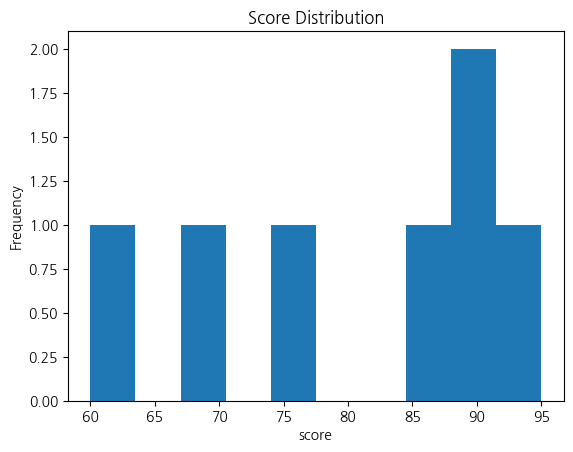

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({'score':[70,85,90,60,75,88,95]})
# df = pd.read_csv('data.csv')

df['score'].plot(kind='hist')
plt.title('Score Distribution')
plt.xlabel('score')
plt.show()


### Pandas `plot(kind=...)`의 다른 그래프 종류

`df.plot()` 메서드는 `kind` 파라미터를 통해 다양한 종류의 그래프를 쉽게 그릴 수 있습니다. `kind`에 지정할 수 있는 주요 값들은 다음과 같습니다:

*   `'line'` (기본값): 선 그래프
*   `'bar'`: 막대 그래프 (수직)
*   `'barh'`: 수평 막대 그래프
*   `'hist'`: 히스토그램
*   `'box'`: 박스 플롯
*   `'kde'` 또는 `'density'`: 커널 밀도 추정 플롯
*   `'area'`: 영역 플롯
*   `'pie'`: 파이 차트
*   `'scatter'`: 산점도 (x, y 인자 필요)
*   `'hexbin'`: 헥스빈 플롯 (x, y 인자 필요)

여기 몇 가지 예시를 들어보겠습니다.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {
    'category': ['A', 'B', 'C', 'D', 'E'],
    'value1': [10, 25, 15, 30, 20],
    'value2': [12, 20, 18, 25, 22],
    'x_data': [1, 2, 3, 4, 5],
    'y_data': [2, 4, 1, 5, 3]
}
df_plot_examples = pd.DataFrame(data)
df_plot_examples['date'] = pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05'])
df_plot_examples = df_plot_examples.set_index('date')

print("예시 데이터프레임:")
display(df_plot_examples)

예시 데이터프레임:


,category,value1,value2,x_data,y_data
date,,,,,
2023-01-01,A,10,12,1,2
2023-01-02,B,25,20,2,4
2023-01-03,C,15,18,3,1
2023-01-04,D,30,25,4,5
2023-01-05,E,20,22,5,3


#### 1. 선 그래프 (`kind='line'`)

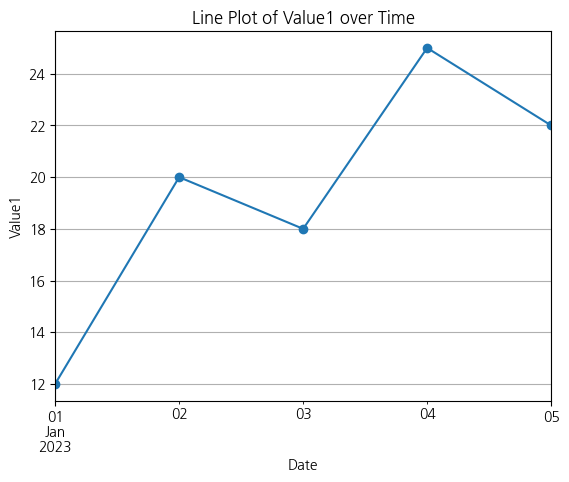

In [ ]:
# 'value1' 컬럼의 선 그래프
df_plot_examples['value2'].plot(kind='line', marker='o')
plt.title('Line Plot of Value1 over Time')
plt.xlabel('Date')
plt.ylabel('Value1')
plt.grid(True)
plt.show()

#### 2. 막대 그래프 (`kind='bar'`)

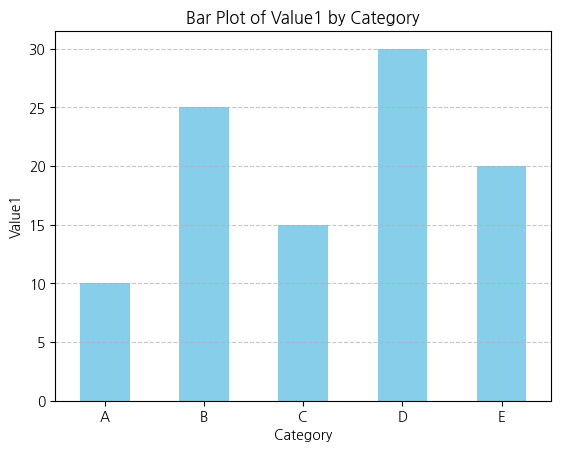

In [ ]:
# 'category'를 인덱스로, 'value1'을 값으로 하는 막대 그래프
df_plot_examples.set_index('category')['value1'].plot(kind='bar', color='skyblue')
plt.title('Bar Plot of Value1 by Category')
plt.xlabel('Category')
plt.ylabel('Value1')
plt.xticks(rotation=0) # x축 레이블 회전 방지
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 3. 산점도 (`kind='scatter'`)

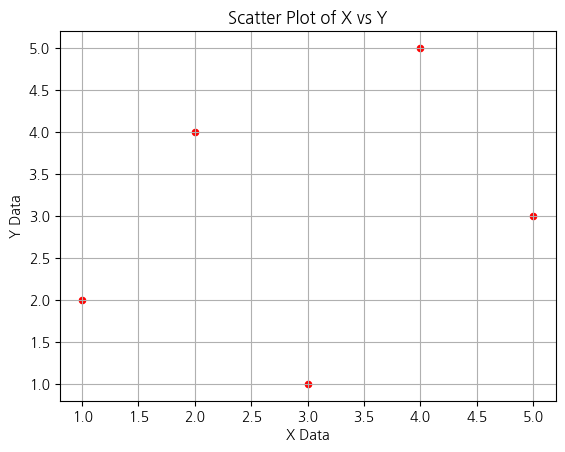

In [ ]:
# 'x_data'와 'y_data' 컬럼을 이용한 산점도
df_plot_examples.plot(kind='scatter', x='x_data', y='y_data', title='Scatter Plot of X vs Y', color='red')
plt.xlabel('X Data')
plt.ylabel('Y Data')
plt.grid(True)
plt.show()

#### 4. 박스 플롯 (`kind='box'`)

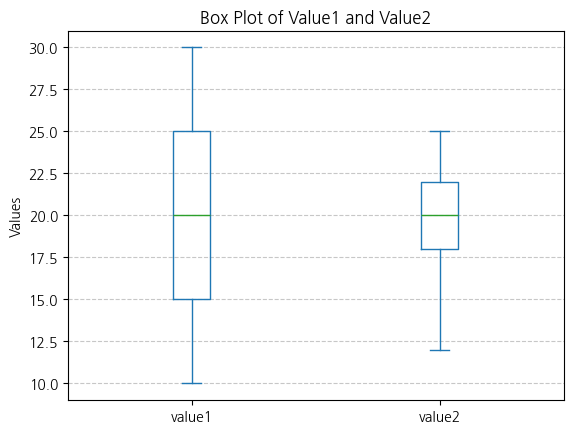

In [ ]:
# 'value1'과 'value2' 컬럼의 박스 플롯 (분포, 이상치 확인)
df_plot_examples[['value1', 'value2']].plot(kind='box', title='Box Plot of Value1 and Value2')
plt.ylabel('Values')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# seaborn 라이브러리
* Seaborn은 파이썬에서 고급 시각화를 위한 라이브러리로, 보다 미적인 그래프 작성을 위한 기본 스타일과 색상 팔레트를 제공한다.
* Matplotlib을 기반으로 구축되었으며, Pandas의 자료구조와도 밀접하게 통합되어 있다.
* Pandas에서도 그래프 작성 기능을 제공하지만, Seaborn을 사용하면 더욱 다양한 그래프를 간결한 코드로 편리하게 작성할 수 있다.
* Seaborn의 가장 큰 장점은 간결함으로, 비교적 짧은 코드만으로도 데이터 분석에 필요한 주요 그래프를 빠르게 생성할 수 있다.
* Seaborn의 그래프 메서드는 Matplotlib이나 Pandas의 그래프 메서드와 유사하여 쉽게 배울 수 있다.

### seaborn 데이터셋 사용하기

In [ ]:
import seaborn as sns
import pandas as pd

# 사용 가능한 데이터셋 확인
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
df = sns.load_dataset("tips")
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
df['sex'].unique()

['Female', 'Male']
Categories (2, object): ['Male', 'Female']

In [ ]:
df['sex'].value_counts()

,count
sex,
Male,157
Female,87


In [ ]:
# 모든 범주형 변수의 고유값 개수
categorical_columns = df.select_dtypes(include=['category']).columns

for col in categorical_columns:
    print(f"{col}. {df[col].nunique()}개의 고유값")
    print(f"  값. {list(df[col].unique())}")
    print()

sex. 2개의 고유값
  값. ['Female', 'Male']

smoker. 2개의 고유값
  값. ['No', 'Yes']

day. 4개의 고유값
  값. ['Sun', 'Sat', 'Thur', 'Fri']

time. 2개의 고유값
  값. ['Dinner', 'Lunch']



### 데이터 분석을 위한 질문들
* 음식값과 팁 사이에 상관관계가 있는가?
* 성별에 따라 팁을 주는 패턴이 다른가?
* 요일별로 매출이나 팁에 차이가 있는가?
* 흡연 여부가 소비 패턴에 영향을 주는가?
* 인원수가 많을 수록 팁을 더 많이 주는가?

## (기본 산점도) 음식가격과 팁의 상관관계

<Axes: xlabel='total_bill', ylabel='tip'>

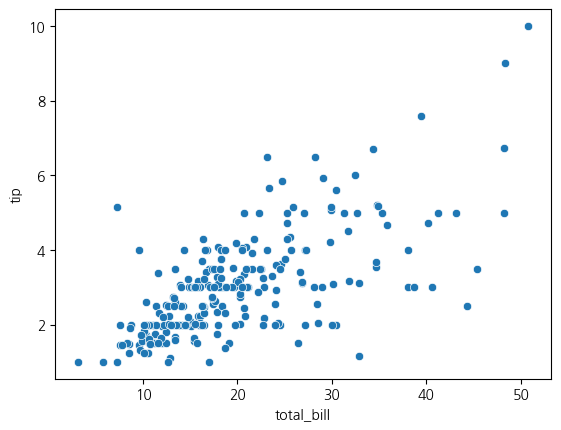

In [ ]:
sns.scatterplot(x=df['total_bill'], y=df['tip'])

## 색상을 활용한 그룹별 분석

<Axes: xlabel='total_bill', ylabel='tip'>

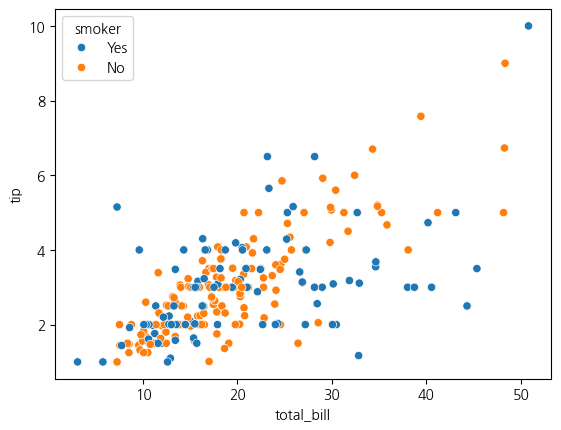

In [ ]:
sns.scatterplot(x=df['total_bill'], y=df['tip'], hue=df['smoker'])

## (버블차트) 크기를 활용한 3차원 정보 표현

<Axes: xlabel='total_bill', ylabel='tip'>

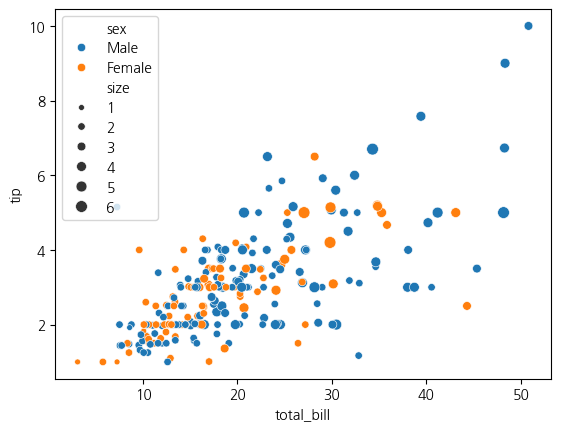

In [ ]:
sns.scatterplot(x=df['total_bill'], y=df['tip'], hue=df['sex'], size=df['size'])

## 다차원 시각화

<Axes: xlabel='total_bill', ylabel='tip'>

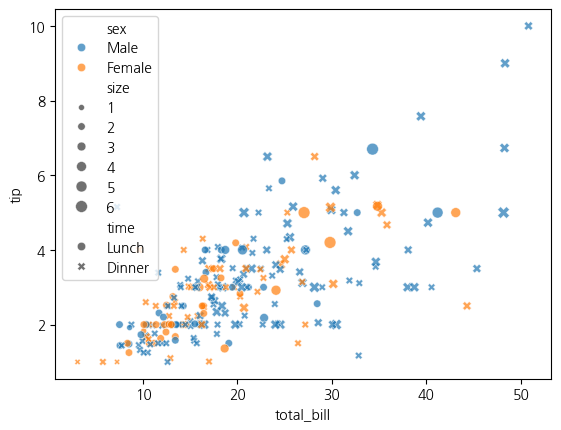

In [ ]:
# 4개 변수를 동시에 표현
sns.scatterplot(x=df['total_bill'], y=df['tip'],
                hue=df['sex'],      # 색상으로 성별 구분
                size=df['size'],    # 크기로 인원수 표현
                style=df['time'],   # 모양으로 시간대 구분
                alpha=0.7)          # 투명도 조절

### (참고) 산점도 vs 막대그래프

<Axes: >

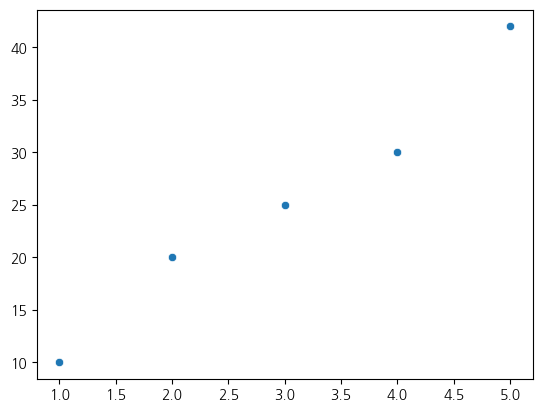

In [ ]:
x = [1, 2, 3, 4, 5]
y = [10, 20, 25, 30, 42]
sns.scatterplot(x=x, y=y)

<Axes: >

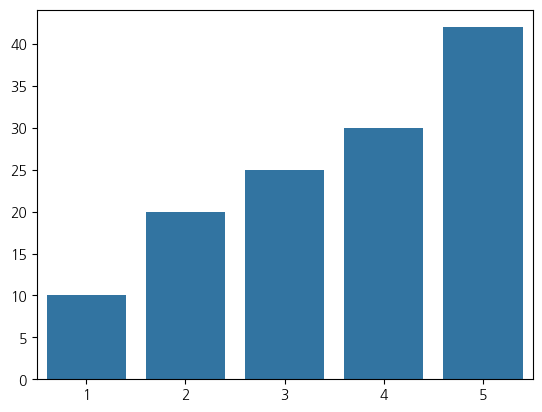

In [ ]:
sns.barplot(x=x, y=y)

# 회귀선(regplot)

In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

## 기본 회귀선 그래프

<Axes: xlabel='total_bill', ylabel='tip'>

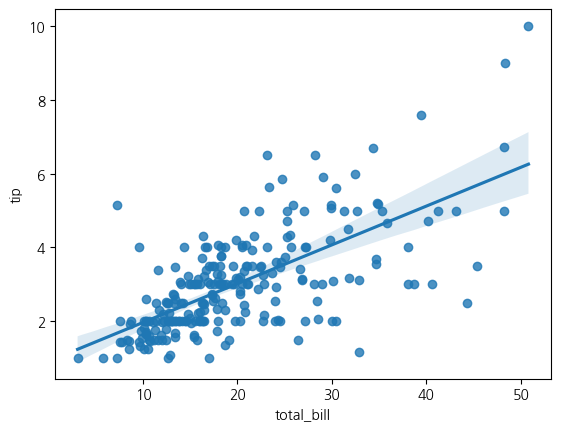

In [ ]:
sns.regplot(x=df['total_bill'], y=df['tip'])

## 회귀선만 표시하기

<Axes: xlabel='total_bill', ylabel='tip'>

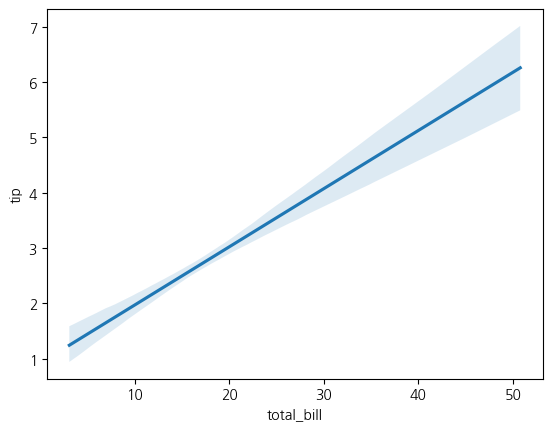

In [ ]:
sns.regplot(x=df['total_bill'], y=df['tip'], scatter = False)

## 신뢰구간의 이해

<Axes: xlabel='total_bill', ylabel='tip'>

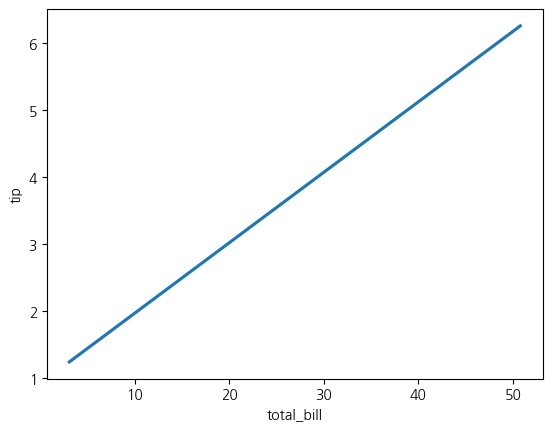

In [ ]:
sns.regplot(x=df['total_bill'], y=df['tip'], scatter = False, ci = None)

# 선그래프(lineplot)

## 기본 선 그래프 생성

<Axes: >

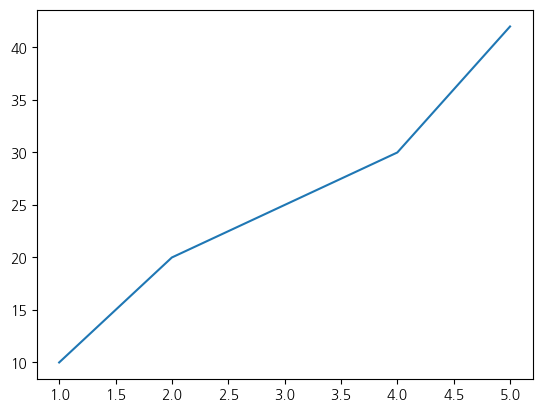

In [ ]:
x= [1, 2, 3, 4, 5]
y= [10, 20, 25, 30, 42]
sns.lineplot(x=x, y=y)

## tips 데이터를 활용한 선그래프 실습

In [ ]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='size', ylabel='tip'>

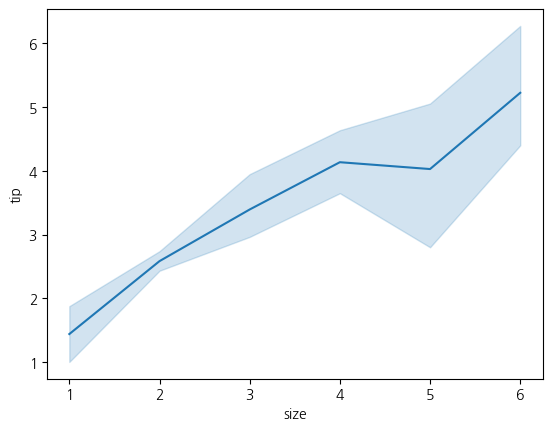

In [ ]:
df = sns.load_dataset('tips')
sns.lineplot(x=df['size'], y=df['tip'])

-----
<div class="alert alert-warning">
[Tip] 신뢰구간의 변경
</div>

In [ ]:
print("min:{}, max:{}".format(min(df[df['size'] == 5]['tip']), max(df[df['size'] == 5]['tip'])))

min:2.0, max:5.14


<Axes: xlabel='size', ylabel='tip'>

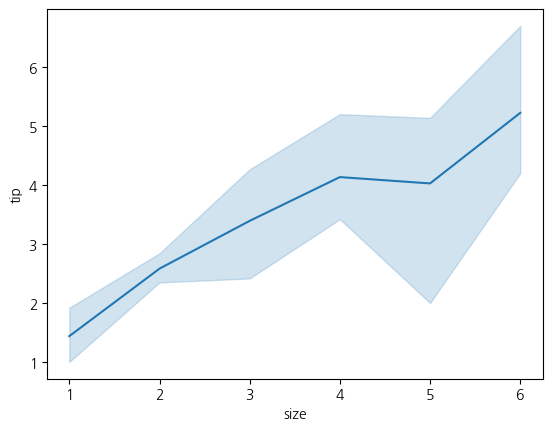

In [ ]:
sns.lineplot(x=df['size'], y=df['tip'], errorbar=('ci', 100))

<Axes: xlabel='size', ylabel='tip'>

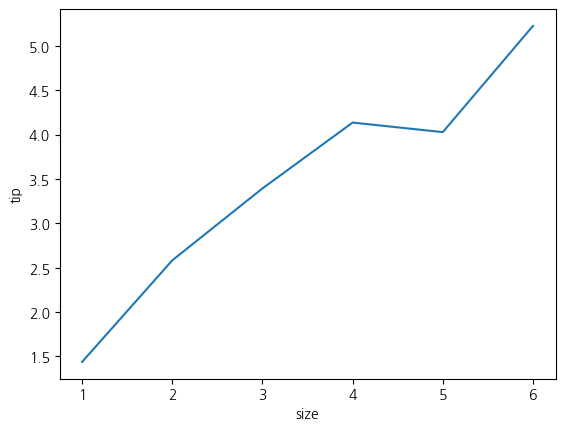

In [ ]:
sns.lineplot(x=df['size'], y=df['tip'], errorbar=None)

----------

<Axes: xlabel='size', ylabel='tip'>

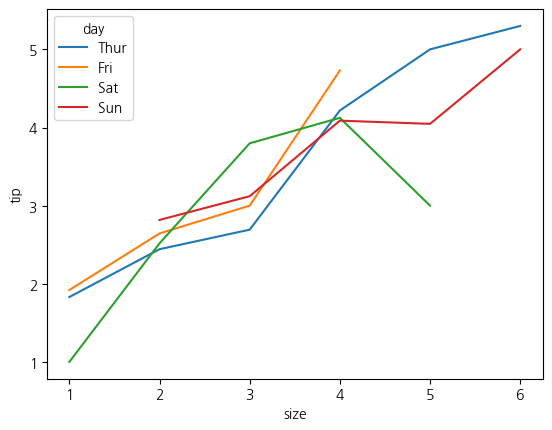

In [ ]:
sns.lineplot(x=df['size'], y=df['tip'], hue=df['day'],  errorbar=None)

-----
<div class="alert alert-warning">
[Tip] hue 속성은 범주형(category) 변수를 지정해주세요!
</div>

<Axes: xlabel='day', ylabel='total_bill'>

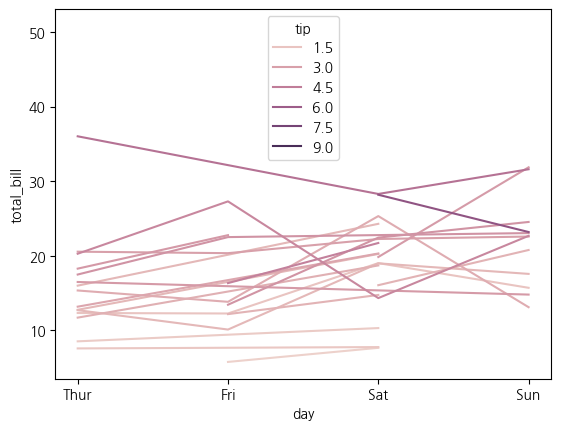

In [ ]:
# hue 속성에 여러 개의 값이 포함된 변수를 지정한 경우
sns.lineplot(x=df['day'], y=df['total_bill'], hue=df['tip'],  errorbar=None)

# 막대그래프(barplot)

In [ ]:
df['size'].unique()

## tips 데이터를 활용한 막대그래프 생성

In [ ]:
sns.barplot(x=df['size'], y=df['tip'])

### 신뢰구간 제거

In [ ]:
sns.barplot(x=df['size'], y=df['tip'], errorbar=None)

-----
<div class="alert alert-warning">
[Tip] 막대의 길이가 비슷한 경우
</div>

In [ ]:
sns.barplot(x=df['day'], y=df['tip'])

------

### countplot: 개수 세기 전용 막대그래프

In [ ]:
sns.countplot(x=df['day'])

In [ ]:
df['day'].value_counts()

### 막대그래프의 변형 : pointplot

-----
<div class="alert alert-warning">
[Tip] pointplot
</div>

In [ ]:
sns.pointplot(x=df['day'], y=df['tip'])

# 박스플롯(boxplot), 바이올린 플롯(violinplot)

In [ ]:
import seaborn as sns
import pandas as pd

In [ ]:
df = sns.load_dataset("tips")
df.head()

In [ ]:
sns.boxplot(x=df['size'], y=df['tip'])

In [ ]:
sns.violinplot(x=df['size'], y=df['tip'])

# 히스토그램(histplot)

In [ ]:
df = sns.load_dataset("tips")
df.head()

## 1. 기본 히스토그램 생성

In [ ]:
sns.histplot(data=df['total_bill'])

## 2. bins(구간)조정

In [ ]:
sns.histplot(data=df['total_bill'], bins=5)

# 기본 히트맵 생성

In [ ]:
pivot_df = df.pivot_table("tip", "day", "size", observed=True)
pivot_df

In [ ]:
sns.heatmap(pivot_df)

# 히트맵 값 표시

In [ ]:
sns.heatmap(pivot_df, annot=True)

# 색상 팔레트 커스터마이징

In [ ]:
# 다양한 색상 팔레트
sns.heatmap(pivot_df, annot=True, cmap='Blues')
sns.heatmap(pivot_df, annot=True, cmap='Reds')
sns.heatmap(pivot_df, annot=True, cmap='viridis')
sns.heatmap(pivot_df, annot=True, cmap='coolwarm')

# 색상 범위 조정

In [ ]:
# 색상 범위 고정
sns.heatmap(pivot_df, annot=True, vmin=0, vmax=6)

In [ ]:
# 중심값 설정
sns.heatmap(pivot_df, annot=True, center=3)

# 색상바와 격자 설정

In [ ]:
# 색상바 제거
sns.heatmap(pivot_df, annot=True, cbar=False)

# 격자선 추가
sns.heatmap(pivot_df, annot=True, linewidths=0.5, linecolor='white')

# 격자 색상 변경
sns.heatmap(pivot_df, annot=True, linewidths=1, linecolor='black')

# 상관관계 히트맵

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 숫자형 변수들의 상관관계
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,           # 값 표시
            cmap='RdBu_r',       # 빨강-파랑 역순
            center=0,            # 0을 중심으로
            square=True,         # 정사각형 셀
            fmt='.2f')           # 소수점 2자리

In [ ]:
# 상삼각형만 표시 (중복 제거)
import numpy as np

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            cmap='RdBu_r',
            center=0)


In [ ]:
# 요일과 시간대별 평균 계산서
time_day_pivot = df.pivot_table('total_bill', 'day', 'time')

plt.figure(figsize=(8, 6))
sns.heatmap(time_day_pivot,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd')

In [ ]:
# 여러 지표를 동시에 표시
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 평균 팁
tip_pivot = df.pivot_table('tip', 'day', 'size')
sns.heatmap(tip_pivot, annot=True, ax=axes[0], cmap='Blues')
axes[0].set_title('평균 팁')

# 평균 계산서
bill_pivot = df.pivot_table('total_bill', 'day', 'size')
sns.heatmap(bill_pivot, annot=True, ax=axes[1], cmap='Greens')
axes[1].set_title('평균 계산서')

# 방문 횟수
count_pivot = df.pivot_table('tip', 'day', 'size', aggfunc='count')
sns.heatmap(count_pivot, annot=True, ax=axes[2], cmap='Oranges')
axes[2].set_title('방문 횟수')

plt.tight_layout()

<Axes: xlabel='size', ylabel='day'>

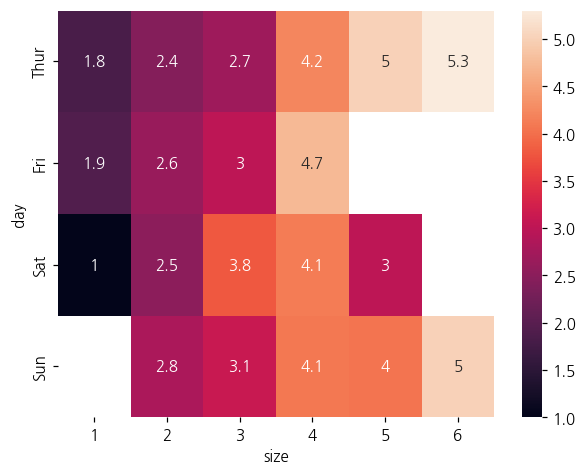

In [ ]:
# 카테고리 순서 지정
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
size_order = [1, 2, 3, 4, 5, 6]

# 순서가 지정된 피봇 테이블
pivot_ordered = df.pivot_table('tip', 'day', 'size')
pivot_ordered = pivot_ordered.reindex(day_order)
pivot_ordered = pivot_ordered.reindex(columns=size_order)

sns.heatmap(pivot_ordered, annot=True)

================================================================

🚢  실제 AIS 데이터로 배우는 Pandas 완전 정복

2024 선박자동식별장치(AIS) 데이터 전처리 & 분석 실습

================================================================

* 파일   : 2024ais.csv  (1,719행 × 12열, cp949 인코딩)
* 환경   : Google Colab / Jupyter Notebook
* 주요 학습 메서드 :
read_csv / info / describe / isnull / value_counts /
to_datetime / dt accessor / map / cut / qcut /
groupby / agg / pivot_table / crosstab /
sort_values / nlargest / merge / apply /
matplotlib / seaborn 시각화





In [ ]:
# ✅ [Colab 전용] 한글 폰트 설치 — 최초 1회만 실행
!apt-get install -y fonts-nanum > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔 폰트 경로 찾기
fm._load_fontmanager(try_read_cache=False)
nanum_path = fm.findfont(fm.FontProperties(family='NanumGothic'))
print(f"폰트 경로: {nanum_path}")

# 전역 폰트 설정
plt.rcParams['font.family']        = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

폰트 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']         = 110

# ──────── 테마 색상 (해양 블루 계열) ────────
C = dict(
    bg='#0A1628', panel='#0F2240', grid='#1A3A5C',
    text='#C8DDEF', accent='#00C6FF',
    c1='#00C6FF', c2='#06D6A0', c3='#FFD166',
    c4='#FF6B6B', c5='#A78BFA', c6='#F97316',
)

### 1. 데이터 구조 탐색

In [ ]:
# ================================================================
# STEP 0.  데이터 로드
# ================================================================
print("=" * 65)
print("  STEP 0 │ 데이터 로드")
print("=" * 65)

# ── 핵심 메서드: pd.read_csv() ──────────────────────────────────
# encoding 파라미터: 한글 포함 파일은 'cp949' 또는 'euc-kr' 사용
df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/0628-0701강의/2024ais.csv', encoding='euc-kr')

print(f"✅  로드 성공  →  {df_raw.shape[0]:,}행 × {df_raw.shape[1]}열")
print()
print("[ 처음 5행 미리보기 ]")
display(df_raw.head())


# ================================================================
# STEP 1.  데이터 구조 탐색
# ================================================================
print("\n" + "=" * 65)
print("  STEP 1 │ 데이터 구조 탐색 (EDA)")
print("=" * 65)

# ── 1-1. info() : 컬럼명 / 타입 / 결측 현황 한눈에 ──────────────
print("\n▶ 1-1.  df.info()")
df_raw.info()

# ── 1-2. describe() : 수치형 기술통계 ───────────────────────────
print("\n▶ 1-2.  df.describe()")
display(df_raw.describe().round(1))

# ── 1-3. isnull() 결측 현황 ─────────────────────────────────────
print("\n▶ 1-3.  결측값 현황  (isnull / sum / mean)")
miss     = df_raw.isnull().sum()
miss_pct = (df_raw.isnull().mean() * 100).round(1)
print(pd.concat([miss, miss_pct], axis=1,
                keys=['결측수', '결측률(%)'])
        [miss > 0])

# ── 1-4. value_counts() ─────────────────────────────────────────
print("\n▶ 1-4.  value_counts() — 수신시각(날짜) 상위 10일")
print(df_raw['수신시각'].value_counts().head(10))

# ── 1-5. nunique() ──────────────────────────────────────────────
print("\n▶ 1-5.  nunique() — 각 컬럼의 고유값 수")
print(df_raw.nunique())


  STEP 0 │ 데이터 로드


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/0628-0701강의/2024ais.csv'

### 2. 데이터 전처리

In [ ]:
# ================================================================
# STEP 2.  데이터 전처리
# ================================================================
print("\n" + "=" * 65)
print("  STEP 2 │ 데이터 전처리")
print("=" * 65)

df = df_raw.copy()   # 원본 보존 → 사본 작업

# ── 2-1. 타입 변환 : to_datetime() ──────────────────────────────
print("\n▶ 2-1.  to_datetime() — 수신시각 문자열 → datetime")
df['수신시각'] = pd.to_datetime(df['수신시각'])
print(f"  변환 전 타입: str  →  변환 후 타입: {df['수신시각'].dtype}")
print(f"  기간: {df['수신시각'].min().date()} ~ {df['수신시각'].max().date()}")

# ── 2-2. dt 접근자(accessor) ────────────────────────────────────
print("\n▶ 2-2.  dt accessor — 날짜 성분 추출")
df['월']    = df['수신시각'].dt.month
df['분기']  = df['수신시각'].dt.quarter
df['요일']  = df['수신시각'].dt.day_name()
print(df[['수신시각', '월', '분기', '요일']].head(4))

# ── 2-3. AIS 원시값 스케일 변환 ─────────────────────────────────
# AIS 표준: 속도·선수방위는 10배 정수로 전송 (0.1 knot 단위)
# 이상코드: 속도=1023, 선수방위=3600이상, 헤딩=511 → "정보없음"
print("\n▶ 2-3.  AIS 원시값 스케일 변환 & 이상코드 NaN 처리")

df['속도_kts']   = df['속도'].where(df['속도'] != 1023) / 10
df['선수방위_deg'] = df['선수방위'].where(df['선수방위'] < 3600) / 10
df['헤딩_deg']   = df['헤딩'].where(df['헤딩'] != 511).astype('float')

print("  속도 이상코드(1023) 처리:",
      (df['속도'] == 1023).sum(), "건 → NaN")
print("  헤딩 이상코드(511)  처리:",
      (df['헤딩'] == 511).sum(), "건 → NaN")
print(df[['속도', '속도_kts', '헤딩', '헤딩_deg']].head(4))

# ── 2-4. 파생변수 : 선박 크기 ───────────────────────────────────
# AIS 메시지 1/2/3: 선박길이 = 선수까지거리(상) + 선미까지거리(하)
print("\n▶ 2-4.  파생변수 생성 — 선박 전장(LOA) / 선폭(B)")
df['전장_m'] = df['선박길이_상'] + df['선박길이_하']
df['선폭_m'] = df['선박길이_좌'] + df['선박길이_우']

# 크기 0 → 미제공(소형선·어선 등)으로 처리
df['전장_m'] = df['전장_m'].replace(0, np.nan)
df['선폭_m'] = df['선폭_m'].replace(0, np.nan)

valid_size = df['전장_m'].notna().sum()
print(f"  크기 정보 제공 선박: {valid_size}척 "
      f"({valid_size/len(df)*100:.1f}%)")
print(df[['선박명', '전장_m', '선폭_m']].dropna().head(5))

# ── 2-5. map() — MMSI 국가코드 → 국적 매핑 ─────────────────────
# MMSI 앞 3자리 = MID(Maritime Identification Digits)
print("\n▶ 2-5.  map() — MMSI 앞 3자리로 국적 분류")
MMSI_COUNTRY = {
    '412': '중국', '413': '중국', '414': '중국',
    '440': '한국', '441': '한국',
    '431': '일본', '432': '일본', '433': '일본',
    '477': '홍콩',
    '636': '라이베리아',
    '352': '파나마', '353': '파나마',
    '538': '마샬군도',
    '563': '싱가포르', '564': '싱가포르',
    '223': '스페인',
    '106': '러시아',
    '416': '대만',
    '796': '인도',
}
df['MID'] = df['선박번호'].astype(str).str[:3]
df['국적'] = df['MID'].map(MMSI_COUNTRY).fillna('기타')
print(df['국적'].value_counts().head(10))

# ── 2-6. cut() / qcut() — 속도 구간 범주화 ─────────────────────
print("\n▶ 2-6.  pd.cut() — 속도 구간 분류")
speed_bins   = [0, 2, 5, 10, 15, 25, 105]
speed_labels = ['정박(0-2)', '초저속(2-5)', '저속(5-10)',
                '중속(10-15)', '순항(15-25)', '고속(25+)']
df['속도구간'] = pd.cut(df['속도_kts'].fillna(0),
                        bins=speed_bins, labels=speed_labels,
                        right=False, include_lowest=True)
print(df['속도구간'].value_counts().sort_index())

print("\n▶ 2-6b. pd.qcut() — 선박 전장 4분위 구간")
df_sized = df[df['전장_m'].notna()].copy()
df_sized['크기구간'] = pd.qcut(df_sized['전장_m'], q=4,
                               labels=['소형', '중소형', '중대형', '대형'],
                               duplicates='drop')
print(df_sized['크기구간'].value_counts().sort_index())

# ── 2-7. fillna() / dropna() ────────────────────────────────────
print("\n▶ 2-7.  fillna() / dropna()")
print(f"  선박명 결측: {df['선박명'].isnull().sum()}건")
df['선박명_표시'] = df['선박명'].fillna('(미등록)')
print("  fillna('(미등록)') 적용 후 결측:",
      df['선박명_표시'].isnull().sum(), "건")

df_clean = df.dropna(subset=['속도_kts', '전장_m'])
print(f"  dropna(subset=['속도_kts','전장_m']): "
      f"{len(df)}행 → {len(df_clean)}행")

# ── 2-8. rename() / astype() ────────────────────────────────────
print("\n▶ 2-8.  rename() — 컬럼명 변경")
df_demo = df[['선박번호', '속도_kts', '헤딩_deg']].copy()
df_demo = df_demo.rename(columns={
    '선박번호': 'mmsi',
    '속도_kts': 'speed_kts',
    '헤딩_deg': 'heading_deg',
})
print(df_demo.head(3))


### 3. 인덱싱 & 필터링

In [ ]:
# ================================================================
# STEP 3.  인덱싱 & 필터링
# ================================================================
print("\n" + "=" * 65)
print("  STEP 3 │ 인덱싱 & 필터링")
print("=" * 65)

# ── 3-1. loc / iloc ─────────────────────────────────────────────
print("\n▶ 3-1.  loc[] — 레이블 기반 선택")
print(df.loc[0:3, ['선박명_표시', '국적', '속도_kts', '전장_m']])

print("\n▶ 3-1b. iloc[] — 위치 기반 선택 (2~4행, 0·8·9열)")
print(df.iloc[2:5, [0, 8, 9]])

# ── 3-2. 불리언 마스킹 ──────────────────────────────────────────
print("\n▶ 3-2.  불리언 마스킹 — 한국 선박 & 속도 10 kts 이상")
mask = (df['국적'] == '한국') & (df['속도_kts'] >= 10)
df_kr_fast = df[mask]
print(f"  조건 충족: {len(df_kr_fast)}건")
print(df_kr_fast[['선박명_표시', '국적', '속도_kts',
                   '선수방위_deg']].head(5))

# ── 3-3. isin() / between() ─────────────────────────────────────
print("\n▶ 3-3.  isin() — 동아시아 주요 국적 필터")
target_nations = ['한국', '일본', '중국', '홍콩']
df_asia = df[df['국적'].isin(target_nations)]
print(f"  동아시아 선박: {len(df_asia)}건")

print("\n▶ 3-3b. between() — 전장 100~300m 선박")
df_mid = df[df['전장_m'].between(100, 300)]
print(f"  전장 100~300m: {len(df_mid)}척")
print(df_mid[['선박명_표시', '전장_m', '선폭_m']].head(5))

# ── 3-4. query() ────────────────────────────────────────────────
print("\n▶ 3-4.  query() — 문자열로 필터 (속도 15 kts 초과)")
df_fast = df.query("속도_kts > 15")
print(f"  결과: {len(df_fast)}건 (평균 속도 "
      f"{df_fast['속도_kts'].mean():.1f} kts)")


  STEP 3 │ 인덱싱 & 필터링

▶ 3-1.  loc[] — 레이블 기반 선택


KeyError: "None of [Index(['선박명_표시', '국적', '속도_kts', '전장_m'], dtype='object')] are in the [columns]"

### 4. 정렬 & 순위

In [ ]:
# ================================================================
# STEP 4.  정렬 & 순위
# ================================================================
print("\n" + "=" * 65)
print("  STEP 4 │ 정렬 & 순위")
print("=" * 65)

# ── 4-1. sort_values() ──────────────────────────────────────────
print("\n▶ 4-1.  sort_values() — 속도 내림차순")
top_speed = (df[['선박명_표시', '국적', '속도_kts', '전장_m']]
             .sort_values('속도_kts', ascending=False)
             .head(10))
print(top_speed.to_string(index=False))

# ── 4-2. nlargest / nsmallest ───────────────────────────────────
print("\n▶ 4-2.  nlargest() — 전장 기준 상위 5척")
print(df[['선박명_표시', '국적', '전장_m', '선폭_m']]
      .nlargest(5, '전장_m')
      .to_string(index=False))

# ── 4-3. rank() ─────────────────────────────────────────────────
print("\n▶ 4-3.  rank() — 속도 순위 (유효값만)")
df_valid = df[df['속도_kts'].notna()].copy()
df_valid['속도_순위'] = df_valid['속도_kts'].rank(
    ascending=False, method='min').astype(int)
print(df_valid[['선박명_표시', '속도_kts', '속도_순위']]
      .sort_values('속도_순위')
      .head(8)
      .to_string(index=False))

### 5. 그룹별 집계

In [45]:
# ================================================================
# STEP 5.  그룹별 집계
# ================================================================
print("\n" + "=" * 65)
print("  STEP 5 │ 그룹별 집계 (GroupBy)")
print("=" * 65)

# ── 5-1. groupby + agg() ────────────────────────────────────────
print("\n▶ 5-1.  groupby('국적').agg() — 국적별 속도 통계")
nation_stats = (df.groupby('국적')['속도_kts']
                  .agg(선박수='count', 평균속도='mean',
                       최고속도='max', 중앙값='median')
                  .round(1)
                  .sort_values('선박수', ascending=False))
print(nation_stats.head(10))

# ── 5-2. 다중 컬럼 집계 ─────────────────────────────────────────
print("\n▶ 5-2.  다중 컬럼 groupby 집계")
multi_agg = (df.groupby('국적')
               .agg(
                   선박수       = ('선박번호', 'count'),
                   평균속도_kts = ('속도_kts',  'mean'),
                   평균전장_m   = ('전장_m',    'mean'),
                   최대전장_m   = ('전장_m',    'max'),
               )
               .round(1)
               .sort_values('선박수', ascending=False)
               .head(8))
print(multi_agg.to_string())

# ── 5-3. 월별 입항 선박 수 ──────────────────────────────────────
print("\n▶ 5-3.  월별 수신 기록 수")
monthly = df.groupby('월').size().rename('기록수')
print(monthly)

# ── 5-4. transform() — 그룹 평균을 원본 행에 붙이기 ─────────────
print("\n▶ 5-4.  transform() — 국적별 평균 속도를 원본 행에 추가")
df['국적별_평균속도'] = (df.groupby('국적')['속도_kts']
                         .transform('mean').round(1))
print(df[['선박명_표시', '국적', '속도_kts',
          '국적별_평균속도']].dropna().head(6))

# ── 5-5. pivot_table() ──────────────────────────────────────────
print("\n▶ 5-5.  pivot_table() — 분기 × 국적 교차 집계 (평균 속도)")
pivot = pd.pivot_table(
    df[df['국적'].isin(target_nations)],
    values='속도_kts',
    index='분기',
    columns='국적',
    aggfunc='mean',
).round(1)
print(pivot)

# ── 5-6. crosstab() ─────────────────────────────────────────────
print("\n▶ 5-6.  crosstab() — 속도구간 × 국적 (건수)")
ct = pd.crosstab(
    df['속도구간'],
    df['국적'],
    margins=True,
    margins_name='합계'
)[target_nations + ['합계']]
print(ct)


  STEP 5 │ 그룹별 집계 (GroupBy)

▶ 5-1.  groupby('국적').agg() — 국적별 속도 통계


KeyError: '국적'

### 6. 선박 apply() & 사용자 정의 함수

In [ ]:
# ================================================================
# STEP 6.  apply() & 사용자 정의 함수
# ================================================================
print("\n" + "=" * 65)
print("  STEP 6 │ apply() & 사용자 정의 함수")
print("=" * 65)

# ── 6-1. apply() — 선박 크기 분류 ──────────────────────────────
print("\n▶ 6-1.  apply() — 전장 기준 선박 등급 분류")

def classify_ship_size(loa):
    """
    전장(Length Over All) 기준 선박 등급
    소형 : LOA < 50 m
    중형 : 50 ≤ LOA < 150 m
    대형 : 150 ≤ LOA < 300 m
    초대형: LOA ≥ 300 m (ULCS, VLCC 등)
    """
    if pd.isna(loa):
        return '미상'
    elif loa < 50:
        return '소형(<50m)'
    elif loa < 150:
        return '중형(50-150m)'
    elif loa < 300:
        return '대형(150-300m)'
    else:
        return '초대형(300m+)'

df['선박등급'] = df['전장_m'].apply(classify_ship_size)
print(df['선박등급'].value_counts())

# ── 6-2. apply() — 방위각 → 8방위 방향 변환 ────────────────────
print("\n▶ 6-2.  apply() — 선수방위 → 8방위 (N/NE/E/SE/S/SW/W/NW)")

def degree_to_compass(deg):
    if pd.isna(deg):
        return '미상'
    dirs = ['N','NE','E','SE','S','SW','W','NW']
    idx  = int((deg + 22.5) / 45) % 8
    return dirs[idx]

df['방위'] = df['선수방위_deg'].apply(degree_to_compass)
print(df['방위'].value_counts())

# ── 6-3. apply(axis=1) — 행 단위 복합 로직 ─────────────────────
print("\n▶ 6-3.  apply(axis=1) — 운항상태 판정")

def get_status(row):
    spd = row['속도_kts']
    if pd.isna(spd):
        return '정보없음'
    elif spd < 0.5:
        return '정박'
    elif spd < 3:
        return '저속이동'
    elif spd < 15:
        return '항해중'
    else:
        return '고속항해'

df['운항상태'] = df.apply(get_status, axis=1)
print(df['운항상태'].value_counts())


### 7.  문자열 & 날짜 처리

In [ ]:
# ================================================================
# STEP 7.  문자열 & 날짜 처리
# ================================================================
print("\n" + "=" * 65)
print("  STEP 7 │ str accessor & 날짜 연산")
print("=" * 65)

# ── 7-1. str accessor ───────────────────────────────────────────
print("\n▶ 7-1.  str accessor")
df_named = df[df['선박명'].notna()].copy()

print("  str.upper() 예시:")
print(df_named['선박명'].str.upper().head(5).tolist())

print("\n  str.contains('HAI') 필터:")
hai_ships = df_named[df_named['선박명'].str.contains('HAI', na=False)]
print(hai_ships[['선박명', '국적', '속도_kts']].head(5))

print("\n  str.len() — 선박명 글자 수 분포:")
print(df_named['선박명'].str.len()
      .describe().round(1))

# ── 7-2. 날짜 연산 ──────────────────────────────────────────────
print("\n▶ 7-2.  날짜 연산 — 월별 수신 건수 추이")
df['월_기간'] = df['수신시각'].dt.to_period('M')
monthly_count = df.groupby('월_기간').size()
print(monthly_count)


### 8.  시각화 대시보드

In [ ]:
# ================================================================
# STEP 8.  시각화 대시보드
# ================================================================
print("\n" + "=" * 65)
print("  STEP 8 │ 시각화 대시보드")
print("=" * 65)

fig = plt.figure(figsize=(20, 14), facecolor=C['bg'])
fig.suptitle(
    "🚢  2024 AIS 데이터 분석 대시보드  │  실제 데이터 기반 Pandas 실습",
    fontsize=16, fontweight='bold', color=C['text'], y=0.98
)

gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.38)

# ──────── 공통 스타일 헬퍼 ────────
def style_ax(ax, title):
    ax.set_facecolor(C['panel'])
    ax.set_title(title, color=C['text'], fontsize=10.5,
                 fontweight='bold', pad=8)
    ax.tick_params(colors=C['text'], labelsize=8.5)
    for sp in ax.spines.values():
        sp.set_edgecolor(C['grid'])
    ax.xaxis.label.set_color(C['text'])
    ax.yaxis.label.set_color(C['text'])

PALETTE = [C['c1'], C['c2'], C['c3'],
           C['c4'], C['c5'], C['c6']]

# ── Chart 1. 속도 분포 히스토그램 ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
valid_speed = df['속도_kts'].dropna()
ax1.hist(valid_speed, bins=40, color=C['c1'], alpha=0.85,
         edgecolor='none', linewidth=0)
ax1.axvline(valid_speed.mean(), color=C['c3'], linewidth=1.8,
            linestyle='--', label=f'평균 {valid_speed.mean():.1f} kts')
ax1.axvline(valid_speed.median(), color=C['c4'], linewidth=1.8,
            linestyle=':', label=f'중앙값 {valid_speed.median():.1f} kts')
ax1.legend(fontsize=8, facecolor=C['panel'],
           labelcolor=C['text'], framealpha=0.7)
ax1.set_xlabel('속도 (knots)')
ax1.set_ylabel('빈도')
ax1.yaxis.grid(True, color=C['grid'], alpha=0.4, linestyle='--')
style_ax(ax1, '① 속도 분포 (hist)')

# ── Chart 2. 국적별 선박 수 가로 막대 ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
nation_cnt = df['국적'].value_counts().head(8)
colors_bar = PALETTE * 2
bars = ax2.barh(nation_cnt.index[::-1], nation_cnt.values[::-1],
                color=colors_bar[:len(nation_cnt)], alpha=0.88,
                height=0.65)
for bar, val in zip(bars, nation_cnt.values[::-1]):
    ax2.text(val + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color=C['text'], fontsize=8.5)
ax2.xaxis.grid(True, color=C['grid'], alpha=0.4, linestyle='--')
ax2.set_xlabel('선박 수')
style_ax(ax2, '② 국적별 선박 수 (barh)')

# ── Chart 3. 월별 수신 건수 꺾은선 ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
monthly_data = df.groupby('월').size()
ax3.plot(monthly_data.index, monthly_data.values,
         color=C['c2'], linewidth=2.2, marker='o',
         markersize=6, markerfacecolor=C['bg'],
         markeredgecolor=C['c2'], markeredgewidth=2)
ax3.fill_between(monthly_data.index, monthly_data.values,
                 alpha=0.15, color=C['c2'])
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels([f'{m}월' for m in range(1, 13)], fontsize=7.5)
ax3.yaxis.grid(True, color=C['grid'], alpha=0.4, linestyle='--')
ax3.set_ylabel('기록 수')
style_ax(ax3, '③ 월별 수신 기록 (line)')

# ── Chart 4. 속도구간 × 국적 (stacked bar) ──────────────────────
ax4 = fig.add_subplot(gs[1, :2])
top4 = ['한국', '중국', '일본', '파나마']
ct_plot = pd.crosstab(df['국적'], df['속도구간'])
ct_plot = ct_plot.loc[ct_plot.index.isin(top4)]
ct_pct  = ct_plot.div(ct_plot.sum(axis=1), axis=0) * 100
bottom  = np.zeros(len(ct_pct))
zone_colors = [C['c1'], C['c2'], C['c3'], C['c4'], C['c5'], C['c6']]
for i, col in enumerate(ct_pct.columns):
    ax4.bar(ct_pct.index, ct_pct[col], bottom=bottom,
            label=str(col), color=zone_colors[i % len(zone_colors)],
            alpha=0.88, width=0.55)
    bottom += ct_pct[col].values
handles, labels = ax4.get_legend_handles_labels()
ax4.legend(handles, labels, fontsize=7.5, facecolor=C['panel'],
           labelcolor=C['text'], framealpha=0.6,
           loc='upper right', ncol=2)
ax4.set_ylabel('비중 (%)')
ax4.yaxis.grid(True, color=C['grid'], alpha=0.3, linestyle='--')
style_ax(ax4, '④ 속도구간 비중 — 국적별 (crosstab + stacked bar)')

# ── Chart 5. 선박등급 도넛 ──────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
grade_cnt = df['선박등급'].value_counts()
grade_cnt = grade_cnt[grade_cnt.index != '미상']
wedges, texts, autotexts = ax5.pie(
    grade_cnt,
    labels=grade_cnt.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(grade_cnt)],
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor=C['bg'], linewidth=2)
)
for t  in texts:    t.set_color(C['text']); t.set_fontsize(8)
for at in autotexts: at.set_color('white');  at.set_fontsize(8)
style_ax(ax5, '⑤ 선박등급 비중 (pie/donut)')

# ── Chart 6. 전장 vs 속도 산점도 ───────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
scatter_df = df.dropna(subset=['전장_m', '속도_kts'])
scatter_df = scatter_df[scatter_df['전장_m'] > 0]
nation_colors = {'한국': C['c1'], '중국': C['c2'],
                 '일본': C['c3'], '기타': C['c4']}
for nat, grp in scatter_df.groupby('국적'):
    key = nat if nat in nation_colors else '기타'
    ax6.scatter(grp['전장_m'], grp['속도_kts'],
                s=18, alpha=0.55,
                color=nation_colors[key],
                label=nat if nat in ['한국', '중국', '일본'] else None)
ax6.set_xlabel('전장 (m)')
ax6.set_ylabel('속도 (kts)')
ax6.yaxis.grid(True, color=C['grid'], alpha=0.4, linestyle='--')
ax6.legend(fontsize=7.5, facecolor=C['panel'],
           labelcolor=C['text'], framealpha=0.6)
style_ax(ax6, '⑥ 전장 vs 속도 (scatter)')

# ── Chart 7. 방위 로즈 다이어그램 ──────────────────────────────
ax7 = fig.add_subplot(gs[2, 1], polar=True)
ax7.set_facecolor(C['panel'])
compass_dirs  = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
compass_cnt   = df['방위'].value_counts().reindex(
    compass_dirs, fill_value=0)
angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
bars7  = ax7.bar(angles, compass_cnt.values,
                 width=2*np.pi/8 * 0.85,
                 color=PALETTE[:8], alpha=0.82,
                 align='center')
ax7.set_xticks(angles)
ax7.set_xticklabels(compass_dirs, color=C['text'], fontsize=9)
ax7.set_yticklabels([])
ax7.set_theta_zero_location('N')
ax7.set_theta_direction(-1)
ax7.spines['polar'].set_edgecolor(C['grid'])
ax7.yaxis.grid(True, color=C['grid'], alpha=0.4)
ax7.xaxis.grid(True, color=C['grid'], alpha=0.4)
ax7.set_title('⑦ 선수방위 로즈 다이어그램',
              color=C['text'], fontsize=10.5,
              fontweight='bold', pad=15)

# ── Chart 8. 운항상태 비중 (가로 막대) ─────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
status_cnt = df['운항상태'].value_counts()
status_pct = (status_cnt / len(df) * 100).round(1)
ax8.barh(status_pct.index[::-1], status_pct.values[::-1],
         color=PALETTE[:len(status_pct)], alpha=0.88, height=0.6)
for i, (val, label) in enumerate(zip(status_pct.values[::-1],
                                     status_pct.index[::-1])):
    ax8.text(val + 0.5, i, f'{val:.1f}%',
             va='center', color=C['text'], fontsize=9)
ax8.set_xlabel('비중 (%)')
ax8.xaxis.grid(True, color=C['grid'], alpha=0.4, linestyle='--')
style_ax(ax8, '⑧ 운항상태 비중 (apply 결과)')

plt.savefig('AIS_2024_대시보드.png',
            dpi=150, bbox_inches='tight',
            facecolor=C['bg'])
plt.show()
print("✅  대시보드 저장 완료")

### 9.  최종 요약 통계 테이블 & 저장

In [46]:
# ================================================================
# STEP 9.  최종 요약 통계 테이블 & 저장
# ================================================================
print("\n" + "=" * 65)
print("  STEP 9 │ 최종 요약 & 저장")
print("=" * 65)

summary = (df.groupby('국적')
             .agg(
                 기록수       = ('선박번호', 'count'),
                 고유선박수   = ('선박번호', 'nunique'),
                 평균속도_kts = ('속도_kts',  'mean'),
                 최고속도_kts = ('속도_kts',  'max'),
                 평균전장_m   = ('전장_m',    'mean'),
                 고속항해비율 = ('운항상태',
                                 lambda x: (x == '고속항해').mean() * 100)
             )
             .round(1)
             .sort_values('기록수', ascending=False))

print("\n▶ 국적별 종합 요약 통계")
print(summary.head(10).to_string())

# 저장
df.to_csv('AIS_2024_전처리완료.csv',
          index=False, encoding='utf-8-sig')
summary.to_csv('AIS_2024_국적별요약.csv',
               encoding='utf-8-sig')
print("\n✅  CSV 저장 완료")
print("    - AIS_2024_전처리완료.csv")
print("    - AIS_2024_국적별요약.csv")

# ── 학습 메서드 인덱스 ───────────────────────────────────────────
print("\n" + "=" * 65)
print("  📚  학습 메서드 인덱스")
print("=" * 65)
print("""
  STEP 0  │  read_csv(encoding=)
  STEP 1  │  head / info / describe / isnull / value_counts / nunique
  STEP 2  │  to_datetime / dt accessor / where / replace / map /
            │  cut / qcut / fillna / dropna / rename / astype
  STEP 3  │  loc / iloc / 불리언 마스킹 / isin / between / query
  STEP 4  │  sort_values / nlargest / nsmallest / rank
  STEP 5  │  groupby / agg / size / transform / pivot_table / crosstab
  STEP 6  │  apply(Series) / apply(axis=1) / 사용자 정의 함수
  STEP 7  │  str accessor (upper/contains/len) / dt.to_period
  STEP 8  │  matplotlib / seaborn 8종 차트
  STEP 9  │  to_csv(encoding='utf-8-sig')
""")


  STEP 9 │ 최종 요약 & 저장


KeyError: '국적'